# 05 Anomaly Detection
Sector-Based Explainable Anomaly Detection


## Setup


In [1]:
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings("ignore")


## Project Paths


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "notebooks").exists() and (PROJECT_ROOT.parent / "notebooks").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

sys.path.insert(0, str(NOTEBOOKS_DIR))

from utils.utils import ensure_project_dirs

ensure_project_dirs()

KPI_PATH = PROJECT_ROOT / "data" / "processed" / "kpi_dataset.csv"

OUTPUTS_DIR = PROJECT_ROOT / "notebooks" / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)


## Load Dataset


In [3]:
df = pd.read_csv(KPI_PATH, parse_dates=["post_date"])

required_columns = [
    "business_name",
    "sector",
    "post_date",
    "post_type",
    "engagement_rate",
    "view_rate",
    "comment_rate",
    "like_rate",
    "view_engagement_rate",
    "discount_percent",
    "hashtags_count",
    "emoji_count",
    "caption_length",
    "views_count",
    "likes_count",
    "comments_count",
    "promo_post",
    "posting_hour",
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df["business_name"] = df["business_name"].astype(str).str.strip()
df["sector"] = df["sector"].astype(str).str.strip()


## Features


In [4]:
features = [
    "engagement_rate",
    "view_rate",
    "comment_rate",
    "like_rate",
    "view_engagement_rate",
    "discount_percent",
    "hashtags_count",
    "emoji_count",
    "caption_length",
]


## Helper Functions


In [5]:
def run_zscore(X, threshold):
    zmax = np.abs(X).max(axis=1)
    return np.where(zmax >= threshold, -1, 1)


def run_iforest(X, contamination):
    model = IsolationForest(
        contamination=contamination,
        random_state=42
    )
    return model.fit_predict(X)


def run_lof(X, n_neighbors, contamination=0.05):
    n_neighbors = min(n_neighbors, max(2, len(X) - 1))

    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination
    )
    return model.fit_predict(X)


def evaluate_method(y_pred, method_name):
    anomaly_count = int((y_pred == -1).sum())
    anomaly_ratio = anomaly_count / len(y_pred)

    target_ratio = 0.05
    balance_score = 1 - abs(anomaly_ratio - target_ratio)

    interpretability = {
        "zscore": 0.95,
        "isolation_forest": 0.80,
        "lof": 0.75,
    }.get(method_name, 0.70)

    final_score = (0.6 * balance_score) + (0.4 * interpretability)

    return anomaly_count, anomaly_ratio, balance_score, interpretability, final_score


def classify_anomaly_type(sector_df, y_pred):
    out = sector_df.copy()
    out["anomaly_label"] = y_pred

    sector_median = out["engagement_rate"].median()

    out["anomaly_type"] = np.where(
        (out["anomaly_label"] == -1)
        & (out["engagement_rate"] >= sector_median),
        "positive_anomaly",
        np.where(
            out["anomaly_label"] == -1,
            "negative_anomaly",
            "normal"
        )
    )

    return out


def add_anomaly_strength(anomalies_df):
    result = anomalies_df.copy()

    result["anomaly_strength"] = np.where(
        result["anomaly_type"] == "positive_anomaly",
        result["engagement_rate"],
        -result["engagement_rate"]
    )

    return result


def summarize_patterns(df_part, sector_name, anomaly_type):
    if df_part.empty:
        return {
            "sector": sector_name,
            "anomaly_type": anomaly_type,
            "count": 0,
            "avg_engagement_rate": np.nan,
            "avg_views": np.nan,
            "avg_likes": np.nan,
            "avg_comments": np.nan,
            "avg_caption_length": np.nan,
            "avg_hashtags": np.nan,
            "avg_emojis": np.nan,
            "most_common_post_type": None,
            "promo_post_ratio": np.nan,
            "most_common_posting_hour": None,
            "insight": "No enough anomalies detected for this group."
        }

    most_common_post_type = (
        df_part["post_type"].mode().iloc[0]
        if not df_part["post_type"].mode().empty
        else None
    )

    most_common_hour = (
        df_part["posting_hour"].mode().iloc[0]
        if not df_part["posting_hour"].mode().empty
        else None
    )

    promo_ratio = df_part["promo_post"].fillna(False).astype(bool).mean()

    if anomaly_type == "positive_anomaly":
        insight = (
            f"In {sector_name}, viral posts are commonly {most_common_post_type} posts, "
            f"with average engagement rate {df_part['engagement_rate'].mean():.4f}. "
            f"They tend to have average views {df_part['views_count'].mean():.0f}, "
            f"average caption length {df_part['caption_length'].mean():.0f}, "
            f"and promo usage ratio {promo_ratio:.2f}."
        )
    else:
        insight = (
            f"In {sector_name}, weak posts are commonly {most_common_post_type} posts, "
            f"with average engagement rate {df_part['engagement_rate'].mean():.4f}. "
            f"They tend to have average views {df_part['views_count'].mean():.0f}, "
            f"average caption length {df_part['caption_length'].mean():.0f}, "
            f"and promo usage ratio {promo_ratio:.2f}."
        )

    return {
        "sector": sector_name,
        "anomaly_type": anomaly_type,
        "count": len(df_part),
        "avg_engagement_rate": df_part["engagement_rate"].mean(),
        "avg_views": df_part["views_count"].mean(),
        "avg_likes": df_part["likes_count"].mean(),
        "avg_comments": df_part["comments_count"].mean(),
        "avg_caption_length": df_part["caption_length"].mean(),
        "avg_hashtags": df_part["hashtags_count"].mean(),
        "avg_emojis": df_part["emoji_count"].mean(),
        "most_common_post_type": most_common_post_type,
        "promo_post_ratio": promo_ratio,
        "most_common_posting_hour": most_common_hour,
        "insight": insight,
    }


## Sector-Based Anomaly Detection


In [6]:
all_anomalies = []
top_positive_rows = []
top_negative_rows = []
experiment_rows = []
pattern_rows = []

sectors = df["sector"].dropna().unique()

for sector in sectors:
    sector_df = df[df["sector"] == sector].copy()

    if len(sector_df) < 10:
        print(f"Skipping sector {sector}: not enough data.")
        continue

    X_raw = sector_df[features].fillna(0)
    X = StandardScaler().fit_transform(X_raw)

    method_outputs = {}

    for threshold in [2, 2.5, 3]:
        y = run_zscore(X, threshold)
        method_key = f"zscore_{threshold}"

        method_outputs[method_key] = {
            "method": "zscore",
            "setting": f"threshold={threshold}",
            "y": y,
        }

    for contamination in [0.03, 0.05, 0.10]:
        y = run_iforest(X, contamination)
        method_key = f"iforest_{contamination}"

        method_outputs[method_key] = {
            "method": "isolation_forest",
            "setting": f"contamination={contamination}",
            "y": y,
        }

    for n_neighbors in [10, 20, 35]:
        y = run_lof(X, n_neighbors, contamination=0.05)
        method_key = f"lof_{n_neighbors}"

        method_outputs[method_key] = {
            "method": "lof",
            "setting": f"n_neighbors={n_neighbors}",
            "y": y,
        }

    for method_key, info in method_outputs.items():
        anomaly_count, anomaly_ratio, balance_score, interpretability, final_score = evaluate_method(
            info["y"],
            info["method"]
        )

        experiment_rows.append({
            "sector": sector,
            "method_key": method_key,
            "method": info["method"],
            "setting": info["setting"],
            "total_posts": len(sector_df),
            "anomaly_count": anomaly_count,
            "anomaly_ratio": anomaly_ratio,
            "balance_score": balance_score,
            "interpretability": interpretability,
            "final_score": final_score,
        })

    sector_experiments = pd.DataFrame(
        [row for row in experiment_rows if row["sector"] == sector]
    )

    best_row = sector_experiments.sort_values(
        "final_score",
        ascending=False
    ).iloc[0]

    best_key = best_row["method_key"]
    best_y = method_outputs[best_key]["y"]

    sector_result = classify_anomaly_type(sector_df, best_y)
    sector_result["best_method"] = best_row["method"]
    sector_result["best_setting"] = best_row["setting"]

    sector_anomalies = sector_result[
        sector_result["anomaly_label"] == -1
    ].copy()

    sector_anomalies = add_anomaly_strength(sector_anomalies)

    all_anomalies.append(sector_anomalies)

    positive = (
        sector_anomalies[
            sector_anomalies["anomaly_type"] == "positive_anomaly"
        ]
        .sort_values("engagement_rate", ascending=False)
        .head(5)
    )

    negative = (
        sector_anomalies[
            sector_anomalies["anomaly_type"] == "negative_anomaly"
        ]
        .sort_values("engagement_rate", ascending=True)
        .head(5)
    )

    top_positive_rows.append(positive)
    top_negative_rows.append(negative)

    pattern_rows.append(
        summarize_patterns(positive, sector, "positive_anomaly")
    )

    pattern_rows.append(
        summarize_patterns(negative, sector, "negative_anomaly")
    )


## Combine Outputs


In [7]:
anomaly_experiments = pd.DataFrame(experiment_rows)

all_anomalies_df = (
    pd.concat(all_anomalies, ignore_index=True)
    if all_anomalies
    else pd.DataFrame()
)

top_positive_anomalies = (
    pd.concat(top_positive_rows, ignore_index=True)
    if top_positive_rows
    else pd.DataFrame()
)

top_negative_anomalies = (
    pd.concat(top_negative_rows, ignore_index=True)
    if top_negative_rows
    else pd.DataFrame()
)

sector_pattern_summary = pd.DataFrame(pattern_rows)

top_anomalies_for_client = pd.concat(
    [top_positive_anomalies, top_negative_anomalies],
    ignore_index=True
)

client_columns = [
    "sector",
    "business_name",
    "post_date",
    "post_type",
    "engagement_rate",
    "views_count",
    "likes_count",
    "comments_count",
    "caption_length",
    "hashtags_count",
    "emoji_count",
    "promo_post",
    "posting_hour",
    "anomaly_type",
    "best_method",
    "best_setting",
]

top_anomalies_for_client = top_anomalies_for_client[
    [col for col in client_columns if col in top_anomalies_for_client.columns]
]


## Save Outputs


In [ ]:
all_anomalies_df.to_csv(
    OUTPUTS_DIR / "sector_based_anomalies.csv",
    index=False
)

top_positive_anomalies.to_csv(
    OUTPUTS_DIR / "top5_positive_anomalies_by_sector.csv",
    index=False
)

top_negative_anomalies.to_csv(
    OUTPUTS_DIR / "top5_negative_anomalies_by_sector.csv",
    index=False
)

top_anomalies_for_client.to_csv(
    OUTPUTS_DIR / "top_anomalies_for_client.csv",
    index=False
)

sector_pattern_summary.to_csv(
    OUTPUTS_DIR / "sector_anomaly_pattern_summary.csv",
    index=False
)

anomaly_experiments.to_csv(
    OUTPUTS_DIR / "sector_anomaly_experiments.csv",
    index=False
)


## Visualizations


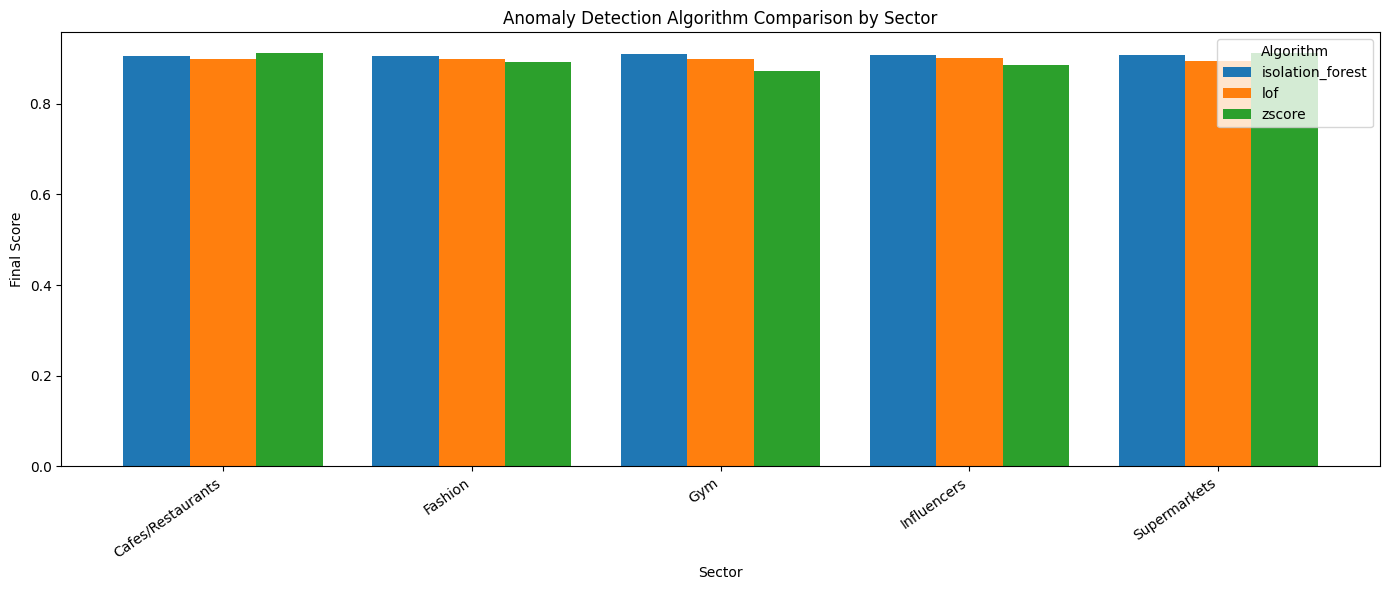

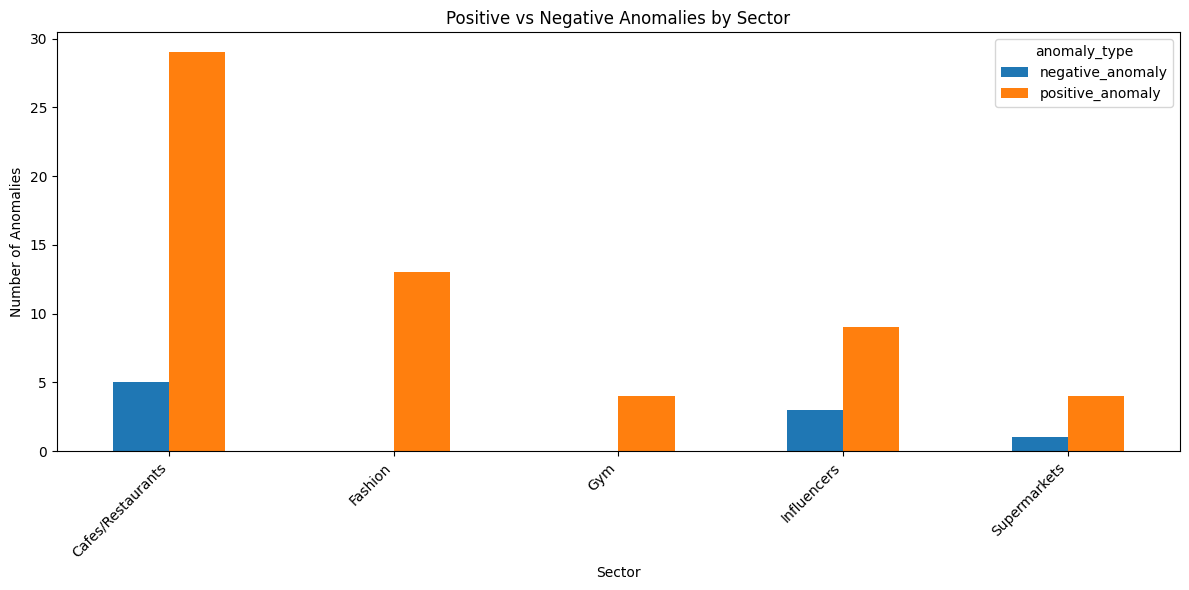

In [ ]:
comparison_df = anomaly_experiments.copy()

pivot_scores = comparison_df.pivot_table(
    index="sector",
    columns="method",
    values="final_score",
    aggfunc="mean"
)

pivot_scores.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Anomaly Detection Algorithm Comparison by Sector")
plt.xlabel("Sector")
plt.ylabel("Final Score")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Algorithm")
plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR / "algorithm_comparison_by_sector.png"
)

plt.show()

if not all_anomalies_df.empty:
    anomaly_counts = (
        all_anomalies_df.groupby(["sector", "anomaly_type"])
        .size()
        .reset_index(name="count")
    )

    pivot_counts = anomaly_counts.pivot(
        index="sector",
        columns="anomaly_type",
        values="count"
    ).fillna(0)

    pivot_counts.plot(kind="bar", figsize=(12, 6))
    plt.title("Positive vs Negative Anomalies by Sector")
    plt.xlabel("Sector")
    plt.ylabel("Number of Anomalies")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "positive_negative_anomalies_by_sector.png")
    plt.show()


## Final Summary


In [9]:
print("Sector-Based Explainable Anomaly Detection completed successfully.")
print()
print("Saved outputs to:")
print(OUTPUTS_DIR)
print()
print("Generated files:")
print("- sector_based_anomalies.csv")
print("- top5_positive_anomalies_by_sector.csv")
print("- top5_negative_anomalies_by_sector.csv")
print("- top_anomalies_for_client.csv")
print("- sector_anomaly_pattern_summary.csv")
print("- sector_anomaly_experiments.csv")
print("- best_anomaly_algorithm_by_sector.png")
print("- positive_negative_anomalies_by_sector.png")


Sector-Based Explainable Anomaly Detection completed successfully.

Saved outputs to:
C:\Users\hanai\marketing\notebooks\outputs

Generated files:
- sector_based_anomalies.csv
- top5_positive_anomalies_by_sector.csv
- top5_negative_anomalies_by_sector.csv
- top_anomalies_for_client.csv
- sector_anomaly_pattern_summary.csv
- sector_anomaly_experiments.csv
- best_anomaly_algorithm_by_sector.png
- positive_negative_anomalies_by_sector.png
